In [17]:
import pickle, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import (GridSearchCV, StratifiedKFold, cross_validate,
                                     train_test_split)
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
MODEL_DIR = Path('model'); MODEL_DIR.mkdir(exist_ok=True)

## 1. Load and clean

In [18]:
df = pd.read_csv('dataset/Training.csv')
df = df.loc[:, ~df.columns.str.startswith('Unnamed')]   # empty trailing column
print('Raw shape:', df.shape)

symptom_cols = [c for c in df.columns if c != 'prognosis']
df[symptom_cols] = df[symptom_cols].fillna(0).astype(int)  # NaN = symptom absent
df = df.dropna(subset=['prognosis'])
print('Missing values left:', int(df.isnull().sum().sum()))

Raw shape: (4920, 133)
Missing values left: 0


In [19]:
n_dup = df.duplicated().sum()
print(f'Duplicate rows: {n_dup} of {len(df)} ({n_dup/len(df):.0%})')
df = df.drop_duplicates().reset_index(drop=True)   # assigned!
print('Shape after de-duplication:', df.shape)
df['prognosis'].value_counts()

Duplicate rows: 4616 of 4920 (94%)
Shape after de-duplication: (304, 133)


prognosis
Hepatitis D                                10
Dengue                                     10
Chicken pox                                10
Migraine                                   10
Hepatitis B                                 9
Hypoglycemia                                9
Common Cold                                 9
Tuberculosis                                9
Hepatitis E                                 9
hepatitis A                                 9
Typhoid                                     9
Hyperthyroidism                             9
Jaundice                                    9
Diabetes                                    9
Pneumonia                                   9
Varicose veins                              8
Malaria                                     8
Hypothyroidism                              8
Alcoholic hepatitis                         8
Chronic cholestasis                         8
Osteoarthristis                             7
Bronchial Asthma        

In [20]:
X = df[symptom_cols]
le = LabelEncoder()
y = le.fit_transform(df['prognosis'])
print('Number of diseases:', len(le.classes_))

Number of diseases: 41


In [21]:
df.size



40432

In [22]:
n_splits = int(min(5, np.bincount(y).min()))
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
print('folds:', n_splits)

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    {'max_depth': [6, 8, 10, 12, 15, 20, None], 'min_samples_leaf': [1, 2, 3, 5]},
    cv=cv, scoring='accuracy', n_jobs=-1).fit(X, y)
best_dt_params = dt_grid.best_params_
print('Decision Tree best params:', best_dt_params, '| CV acc:', round(dt_grid.best_score_, 4))

rf_grid = GridSearchCV(
    RandomForestClassifier(n_estimators=150, random_state=RANDOM_STATE, n_jobs=-1),
    {'max_depth': [8, 12, None], 'min_samples_leaf': [1, 2, 3], 'max_features': ['sqrt', 0.3]},
    cv=cv, scoring='accuracy', n_jobs=1).fit(X, y)
best_rf_params = rf_grid.best_params_
print('Random Forest best params:', best_rf_params, '| CV acc:', round(rf_grid.best_score_, 4))

folds: 5
Decision Tree best params: {'max_depth': None, 'min_samples_leaf': 3} | CV acc: 0.6279
Random Forest best params: {'max_depth': 12, 'max_features': 'sqrt', 'min_samples_leaf': 1} | CV acc: 1.0


## 2. Compare all models fairly


In [23]:
def drop_symptoms(X_df, keep_frac, seed):
    """Randomly keep only keep_frac of each row's symptoms (at least 1)."""
    rng = np.random.default_rng(seed)
    arr = X_df.values.copy()
    for r in range(arr.shape[0]):
        ones = np.flatnonzero(arr[r])
        if len(ones) > 1:
            k = max(1, int(round(len(ones) * keep_frac)))
            drop = rng.choice(ones, size=len(ones) - k, replace=False)
            arr[r, drop] = 0
    return pd.DataFrame(arr, columns=X_df.columns)

models = {
    'DecisionTree': DecisionTreeClassifier(random_state=RANDOM_STATE, **best_dt_params),
    'RandomForest': RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE,
                                           n_jobs=-1, **best_rf_params),
    'SVC(linear)': SVC(kernel='linear'),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'MultinomialNB': MultinomialNB(),
}

rows = []
for name, m in models.items():
    tr, te, part = [], [], []
    for f, (a, b) in enumerate(cv.split(X, y)):
        m.fit(X.iloc[a], y[a])
        tr.append(accuracy_score(y[a], m.predict(X.iloc[a])))
        te.append(accuracy_score(y[b], m.predict(X.iloc[b])))
        Xb = drop_symptoms(X.iloc[b], keep_frac=0.6, seed=f)
        part.append(accuracy_score(y[b], m.predict(Xb)))
    rows.append((name, np.mean(tr), np.mean(te), np.std(te), np.mean(part)))

res = pd.DataFrame(rows, columns=['model', 'train_acc', 'cv_test_acc', 'cv_std', 'partial_symptom_acc'])
res['train-test gap'] = res.train_acc - res.cv_test_acc
res['overfit?'] = res['train-test gap'] > 0.10
res = res.sort_values('partial_symptom_acc', ascending=False).reset_index(drop=True)
res.round(4)

,model,train_acc,cv_test_acc,cv_std,partial_symptom_acc,train-test gap,overfit?
0,RandomForest,1.0000,1.0000,0.0000,0.9407,0.00,False
1,MultinomialNB,0.9770,0.9769,0.0082,0.9145,0.00,False
2,SVC(linear),1.0000,1.0000,0.0000,0.8945,0.00,False
3,KNN,1.0000,1.0000,0.0000,0.8846,0.00,False
4,DecisionTree,0.9679,0.6279,0.0670,0.3684,0.34,True


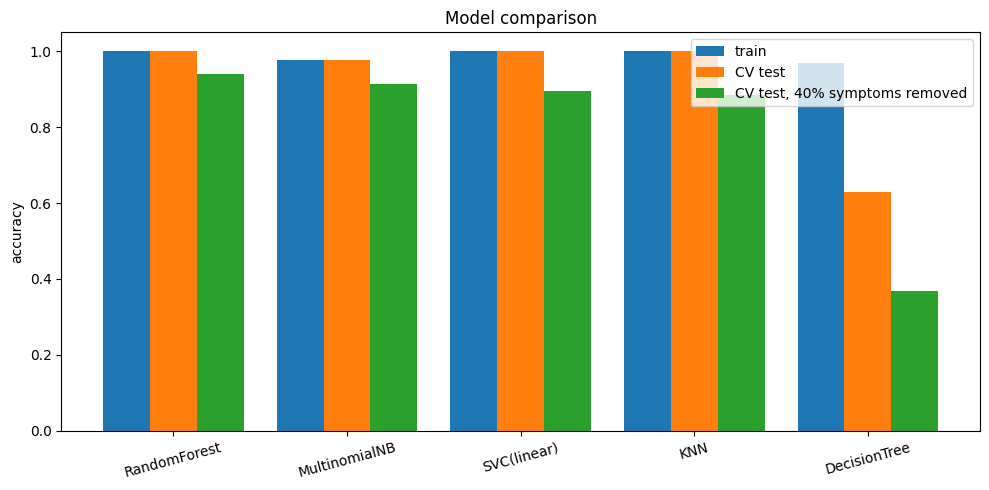

In [24]:
x = np.arange(len(res)); w = 0.27
plt.figure(figsize=(10, 5))
plt.bar(x - w, res.train_acc, w, label='train')
plt.bar(x, res.cv_test_acc, w, label='CV test')
plt.bar(x + w, res.partial_symptom_acc, w, label='CV test, 40% symptoms removed')
plt.xticks(x, res.model, rotation=15); plt.ylim(0, 1.05); plt.ylabel('accuracy')
plt.title('Model comparison'); plt.legend(); plt.tight_layout(); plt.show()

## 3. Decision Tree vs Random Forest: hold-out test

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
X_test_part = drop_symptoms(X_test, keep_frac=0.6, seed=0)

main_models = {'DecisionTree': models['DecisionTree'], 'RandomForest': models['RandomForest']}
for name, m in main_models.items():
    m.fit(X_train, y_train)
    print('=' * 60); print(name)
    print('Train accuracy          :', round(accuracy_score(y_train, m.predict(X_train)), 4))
    print('Test accuracy           :', round(accuracy_score(y_test, m.predict(X_test)), 4))
    print('Test (40% symptoms cut) :', round(accuracy_score(y_test, m.predict(X_test_part)), 4))
    print(classification_report(y_test, m.predict(X_test), target_names=le.classes_, zero_division=0))

DecisionTree
Train accuracy          : 0.9547
Test accuracy           : 0.7049
Test (40% symptoms cut) : 0.377
                                         precision    recall  f1-score   support

(vertigo) Paroymsal  Positional Vertigo       0.50      1.00      0.67         1
                                   AIDS       0.00      0.00      0.00         1
                                   Acne       0.00      0.00      0.00         1
                    Alcoholic hepatitis       1.00      0.50      0.67         2
                                Allergy       0.10      1.00      0.18         1
                              Arthritis       0.00      0.00      0.00         1
                       Bronchial Asthma       1.00      1.00      1.00         1
                   Cervical spondylosis       0.00      0.00      0.00         1
                            Chicken pox       1.00      1.00      1.00         2
                    Chronic cholestasis       0.00      0.00      0.00        

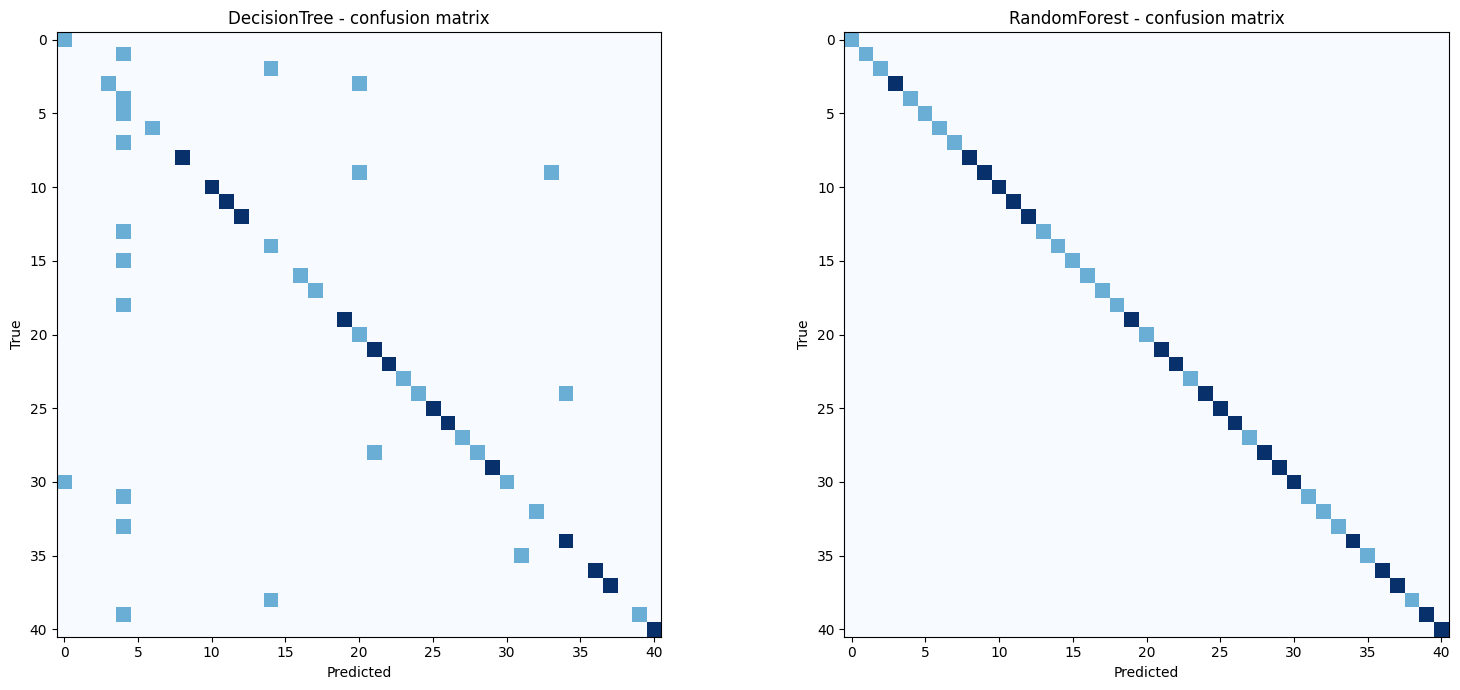

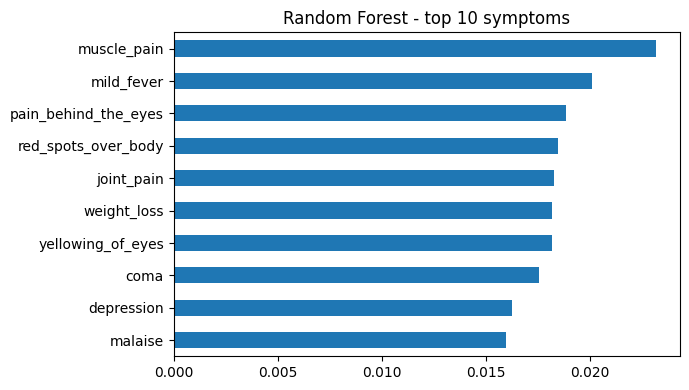

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, (name, m) in zip(axes, main_models.items()):
    cm = confusion_matrix(y_test, m.predict(X_test))
    im = ax.imshow(cm, cmap='Blues'); ax.set_title(f'{name} - confusion matrix')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.tight_layout(); plt.show()

# most important symptoms for the Random Forest
imp = pd.Series(main_models['RandomForest'].feature_importances_, index=X.columns).nlargest(10)
imp[::-1].plot.barh(figsize=(7, 4), title='Random Forest - top 10 symptoms'); plt.tight_layout(); plt.show()

## 4. Train final Decision Tree and Random Forest on all unique rows and save the `.pkl` files

In [27]:
final = {
    'dtc': DecisionTreeClassifier(random_state=RANDOM_STATE, **best_dt_params),
    'rf': RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1, **best_rf_params),
}
for name, m in final.items():
    m.fit(X, y)
    with open(MODEL_DIR / f'{name}.pkl', 'wb') as f:
        pickle.dump(m, f)
    print(f'saved model/{name}.pkl')

# symptom order + disease labels, so main.py always matches the trained model
symptoms_dict = {s: i for i, s in enumerate(symptom_cols)}
diseases_list = {i: d for i, d in enumerate(le.classes_)}
with open(MODEL_DIR / 'meta.pkl', 'wb') as f:
    pickle.dump({'symptoms_dict': symptoms_dict, 'diseases_list': diseases_list}, f)
print('saved model/meta.pkl')

saved model/dtc.pkl
saved model/rf.pkl
saved model/meta.pkl


## 5. Reload and predict 

In [28]:
dtc = pickle.load(open('model/dtc.pkl', 'rb'))

description = pd.read_csv('dataset/description.csv')
precaution  = pd.read_csv('dataset/precautions_df.csv')
medication  = pd.read_csv('dataset/medications.csv')
diets       = pd.read_csv('dataset/diets.csv')
workout     = pd.read_csv('dataset/workout_df.csv')

def get_predicted_value(patient_symptoms):
    vec = pd.DataFrame(np.zeros((1, len(symptoms_dict))), columns=list(symptoms_dict))
    unknown = []
    for s in patient_symptoms:
        if s in symptoms_dict: vec.loc[0, s] = 1
        else: unknown.append(s)
    if vec.values.sum() == 0:
        return None, unknown
    return diseases_list[int(dtc.predict(vec)[0])], unknown

def helper(dis):
    desc = ' '.join(description[description['Disease'] == dis]['Description'])
    pre  = precaution[precaution['Disease'] == dis][['Precaution_1','Precaution_2','Precaution_3','Precaution_4']].values
    pre  = list(pre[0]) if len(pre) else []
    med  = list(medication[medication['Disease'] == dis]['Medication'])
    die  = list(diets[diets['Disease'] == dis]['Diet'])
    wrk  = list(workout[workout['disease'] == dis]['workout'])
    return desc, pre, med, die, wrk

In [29]:
symptoms = 'itching, skin rash, nodal skin eruptions'      # <- change me
user_symptoms = [s.strip().lower().replace(' ', '_') for s in symptoms.split(',')]

disease, unknown = get_predicted_value(user_symptoms)
if unknown: print('Unknown symptoms ignored:', unknown)
if disease is None:
    print('No valid symptoms entered.')
else:
    desc, pre, med, die, wrk = helper(disease)
    print('Predicted disease:', disease); print('\nDescription:', desc)
    for title, items in [('Precautions', pre), ('Medications', med), ('Diet', die), ('Workout', wrk)]:
        print(f'\n{title}:')
        for i, it in enumerate(items, 1): print(f'  {i}. {it}')

Predicted disease: Fungal infection

Description: Fungal infection is a common skin condition caused by fungi.

Precautions:
  1. bath twice
  2. use detol or neem in bathing water
  3. keep infected area dry
  4. use clean cloths

Medications:
  1. ['Antifungal Cream', 'Fluconazole', 'Terbinafine', 'Clotrimazole', 'Ketoconazole']

Diet:
  1. ['Antifungal Diet', 'Probiotics', 'Garlic', 'Coconut oil', 'Turmeric']

Workout:
  1. Avoid sugary foods
  2. Consume probiotics
  3. Increase intake of garlic
  4. Include yogurt in diet
  5. Limit processed foods
  6. Stay hydrated
  7. Consume green tea
  8. Eat foods rich in zinc
  9. Include turmeric in diet
  10. Eat fruits and vegetables
